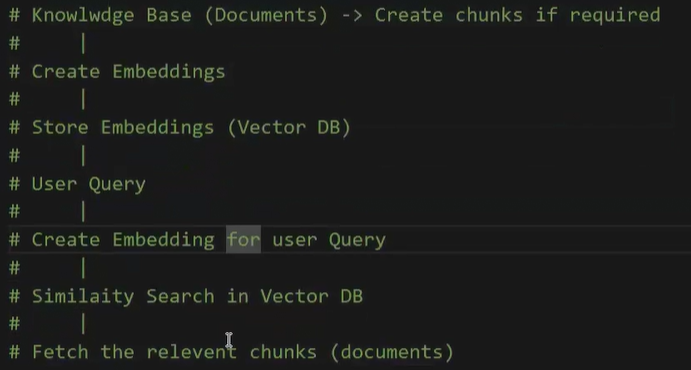

In [2]:
## Basic AI Pipeline:
# Query + LLM -> Output


## RAG Pipieline:

#   Query
#     |
# Fetch the Relevant Chunk (document) (Retriever)
#     |
# Add this retrieved document as context to the LLM
#     |
# Create Prompt (context + query)
#     |
# LLM Call

## Retriever

In [ ]:
# It is a tool (function) that fetches or retrieves the relevant chunk (document) from the knowledge base.

In [8]:
import numpy as np
from openai import OpenAI
import os

In [6]:
llm_client = OpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'))
llm_client

### Step 1: Create/Get Chunks

In [3]:
chunks = [
    "Python is a programming language used for AI and machine learning.",
    "ChromaDB is a vector database used in retrieval augmented generation.",
    "Embeddings convert text into numerical vectors.",
    "FAISS is a library developed by Facebook for fast similarity search.",
    "Neural networks are used in deep learning applications."
]

### Step 2: Create Embeddings of Chunks

In [4]:
def get_embeddings(llm_client, text):
    response = llm_client.embeddings.create(
        model='text-embedding-3-small',
        input=text
    )

    return response.data[0].embedding

In [7]:
embeddings = []

for chunk in chunks:
    embedding = get_embeddings(llm_client=llm_client, text=chunk)
    embeddings.append(embedding)

In [13]:
chunk_embeddings = np.array(embeddings)
chunk_embeddings

array([[-0.02275337, -0.01865853, -0.00778888, ..., -0.05883426,
        -0.0114636 ,  0.0031339 ],
       [ 0.03462372,  0.06587309,  0.04706967, ..., -0.0065653 ,
         0.02094295, -0.01435319],
       [-0.02059904,  0.01608261,  0.03771333, ..., -0.01035684,
        -0.00359652,  0.04103761],
       [-0.03680114, -0.02335072, -0.00020274, ...,  0.04375136,
        -0.04630144,  0.00078792],
       [-0.03863996, -0.03416201, -0.00301906, ...,  0.01090105,
         0.02567217,  0.02392962]], shape=(5, 1536))

### Step 3: Similarity Search